In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/periibrahimli/titanic-dataset/Titanic-Dataset.csv


In [2]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/periibrahimli/titanic-dataset/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.isnull().sum()
# burada fare ve sibsp sutunlari silinse daha yaxsi olar

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
import numpy as np
df['Age'].fillna(df['Age'].median())
# çünki birinin yasi daha böyük digerininki daha kiçikdir və biz ortalamni tapmaq isdesek bu dogru olmayacaq birinin yasi 20 digerininki
# 80 olanda ortalama yas 50 olur ve bu hec uygun deyil hem de null deyerler olduguna gore 


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [5]:
df.drop('Cabin', axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [6]:
df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [7]:
df['Embarked'].fillna('S')

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [8]:
df.groupby('Survived')['Age'].mean()
# düşünürəmki yaşı az olanlar daha çevik olub deyə ölməyiblər yaşlılar isə daha dözümsüz olduguna göre yaşamayıblar

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [9]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [10]:
df.groupby('Pclass')['Survived'].mean()*100
# məncə sinifin buna təsiri var çünki vip yerlər daha təhlüksiz ola bilər

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [11]:
df.groupby('Sex')['Survived'].mean()*100 
#məncə birinci qadınlar və uşaqlar xilas edildiyinə görə onların yaşama ehtimalı daha çoxdur

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [12]:
df.groupby(['Sex','Pclass'])['Fare'].mean()
# qadınlarda qiymət və siniflər arasında kəskin fərqlər var ən yüksək 1 ci sinifdi 

Sex     Pclass
female  1         106.125798
        2          21.970121
        3          16.118810
male    1          67.226127
        2          19.741782
        3          12.661633
Name: Fare, dtype: float64

In [13]:
df['FamilySize'] = df['SibSp']+df['Parch']+1
df['FamilySizee'] = df.groupby(['FamilySize', 'Parch'])['Survived'].transform('mean')
df['FamilySizee']

0      0.520325
1      0.520325
2      0.303538
3      0.520325
4      0.303538
         ...   
886    0.303538
887    0.303538
888    0.631579
889    0.303538
890    0.303538
Name: FamilySizee, Length: 891, dtype: float64

In [14]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

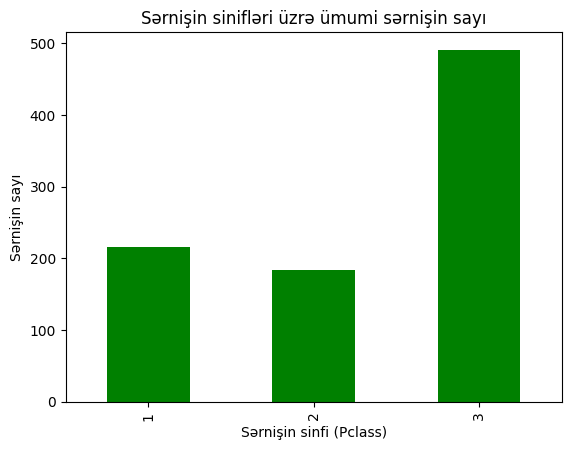

In [15]:
import matplotlib.pyplot as plt
pclass_counts = df['Pclass'].value_counts().sort_index()
pclass_counts.plot(kind='bar', color='green')
plt.xlabel('Sərnişin sinfi (Pclass)')
plt.ylabel('Sərnişin sayı')
plt.title('Sərnişin sinifləri üzrə ümumi sərnişin sayı')
plt.show()

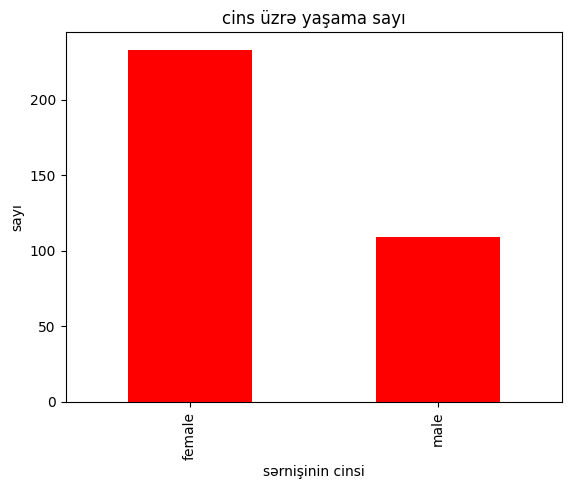

In [16]:
live_counts=df.groupby('Sex')['Survived'].sum()
live_counts.plot(kind='bar',color='red')
plt.xlabel('sərnişinin cinsi')
plt.ylabel('sayı')
plt.title('cins üzrə yaşama sayı')
plt.show()

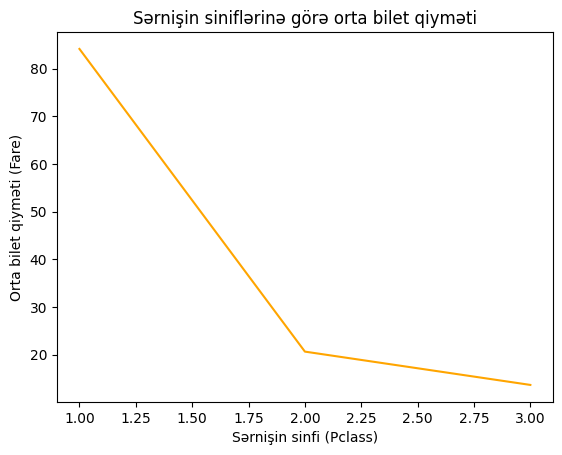

In [17]:
avg_fare = df.groupby('Pclass')['Fare'].mean()
avg_fare.plot(kind='line',  color='orange')
plt.xlabel('Sərnişin sinfi (Pclass)')
plt.ylabel('Orta bilet qiyməti (Fare)')
plt.title('Sərnişin siniflərinə görə orta bilet qiyməti')
plt.show()

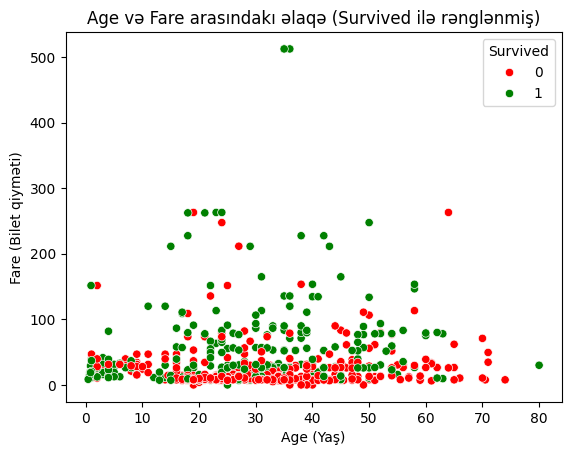

In [18]:
import seaborn as sns
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette={0:'red', 1:'green'})
plt.xlabel('Age (Yaş)')
plt.ylabel('Fare (Bilet qiyməti)')
plt.title('Age və Fare arasındakı əlaqə (Survived ilə rənglənmiş)')
plt.show()

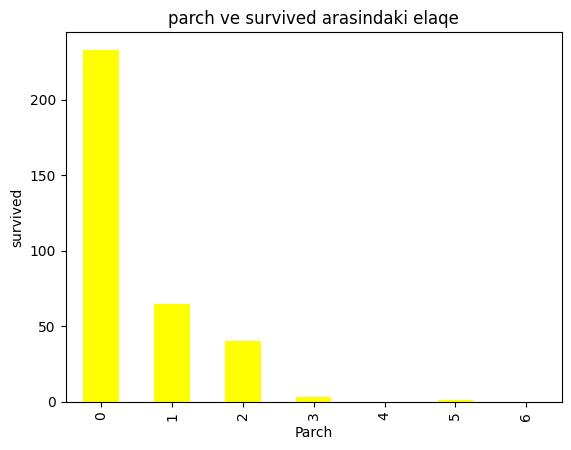

In [19]:
say=df.groupby('Parch')['Survived'].sum()
say.plot(kind='bar',color='yellow')
plt.xlabel('Parch')
plt.ylabel('survived')
plt.title('parch ve survived arasindaki elaqe')
plt.show()